In [ ]:
# Append path to deconversation modules
import sys
import os
import scanpy as sc
sys.path.append('../deconversation')

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Import associated modules
from pseudobulk import *
from preprocessing import *

In [ ]:
# Path to single-cell RNAseq data 
path = "/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/10xpbmcflex/10xpbmcflex_symbol.h5ad"

In [ ]:
path_ref = "/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/deconvBench/hao800_id.h5ad"

### Step 1: Prep data

In [6]:
# Read the h5ad file (just to explore columns and variables)
adata = sc.read_h5ad(path)

# Subset to select cell types
adata = adata[adata.obs["broad_type"].isin(['B cells', 'Monocytes', 'NK cells', 'T cells'])]
adata = adata.copy()

# Remove unmapped genes
#adata.var.index = adata.var["gene_id"]
adata.var.index = adata.var["gene_name"]
adata = adata[:, adata.var.index.notnull()]

# Prep data for geneformer 
#adata = load_and_prep_data(adata= adata, cell_type_col= "broad_type", mode="geneformer")

# Prep data for cell2sentence 
#adata = load_and_prep_data(adata= adata, cell_type_col= "broad_type", mode="c2s", organism="Homo Sapiens")

In [7]:
# Read the h5ad file (just to explore columns and variables)
adata_ref = sc.read_h5ad(path_ref)

# Subset to select cell types
adata_ref = adata_ref[adata_ref.obs["broad_type"].isin(['B cells', 'Monocytes', 'NK cells', 'T cells'])]
adata_ref = adata_ref.copy()

# Remove unmapped genes
#adata_ref.var.index = adata_ref.var["gene_id"]
adata_ref.var.index = adata_ref.var["gene_name"]
adata_ref = adata_ref[:, adata_ref.var.index.notnull()]

# Prep data for geneformer 
#adata_ref = load_and_prep_data(adata= adata_ref, cell_type_col= "broad_type", mode="geneformer")

# Prep data for cell2sentence
#adata_ref = load_and_prep_data(adata= adata_ref, cell_type_col= "broad_type", mode="c2s", organism="Homo Sapiens")

In [8]:
adata.obs["broad_type"].value_counts()

broad_type
T cells      3264
Monocytes    1182
NK cells      863
B cells       476
Name: count, dtype: int64

In [9]:
adata_ref.obs["broad_type"].value_counts()

broad_type
B cells      800
Monocytes    800
NK cells     800
T cells      800
Name: count, dtype: int64

### Step 2: Create pseudobulk

In [12]:
# Create pseudobulk and cell type prortions (ground truth)
pseudo_bulk, cell_prop = generate_pseudobulk(adata = adata,
                                             cell_type_col = "broad_type",
                                             n_pseudobulks = 250,
                                             target_proportion_min = 0.1,
                                             target_proportion_max = 0.80, 
                                             n_cells_per_pseudobulk = 300, 
                                             random_state = 42 
                                            )

### Step 3: Create signature matrix

In [13]:
# Create signature matrix from single cell data
sig_mat = create_signature_matrix(adata = adata_ref,
                                  sample_col = "batch", # sample id column
                                  cell_type_col = "broad_type",
                                  groupby = "broad_type",
                                  sample_ids = None,
                                  output_path = None)

# Transpose for embedding extraction
# Columns should be gene names or ensembl ids (ensembl ids for geneformer)
sig_mat = sig_mat.T

In [14]:
#pseudo_bulk.to_csv("../scripts/pseudobulk_data_flex_symbol.csv")

### Step 4: Extract Embeddings

In [15]:
from embeddings import *

geneformer is not installed. Skipping related functions.
cell2sentence is not installed. Skipping related functions.
cellhermes successfully imported.
scGPT is not installed. Skipping related functions.
scVI is not installed. Skipping related functions.


In [16]:
from deconvolution import *

<h4 style="color:blue">Geneformer</h4>

In [20]:
# sig_mat_gf_embed = extract_embs(
#     bulk_df = sig_mat,
#     mode = "geneformer", 
#     temp_output_dir = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/", 
#     model_path= "ctheodoris/Geneformer",
#     delete_temp_files = True
# )

In [21]:
pseudo_bulk_embed = extract_embs(
    bulk_df = pseudo_bulk, 
    mode = "geneformer",
    temp_output_dir = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/", 
    model_path= "ctheodoris/Geneformer",
    delete_temp_files = True
)

Pseudobulk AnnData saved to: /gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/temp/gf_tokens.h5ad
Starting Geneformer tokenization...
Tokenizing /gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/temp/gf_tokens.h5ad


100%|██████████| 1/1 [00:00<00:00, 103.36it/s]

/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/temp/gf_tokens.h5ad has no column attribute 'filter_pass'; tokenizing all cells.


Creating dataset.
Loading Geneformer model...
Loading tokenized dataset...


CLS token present in token dictionary, excluding from average.
EOS token present in token dictionary, excluding from average.


Extracting Geneformer embeddings...


  0%|          | 0/5 [00:00<?, ?it/s]

In [22]:
# Run NNLS
cell_prop_pred = run_deconv(bulk_df = pseudo_bulk_embed.T, 
                            signature_df = sig_mat_gf_embed.T, 
                            normalize = True)

Using 1152 common features.
Running deconvolution...


In [23]:
cell_prop_pred.head()

broad_type,B cells,Monocytes,NK cells,T cells
NK cells_PB1,0.015379,0.475276,0.096078,0.413267
B cells_PB2,0.693466,0.216940,0.087150,0.002444
Monocytes_PB3,0.018777,0.765426,0.001945,0.213852
NK cells_PB4,0.069633,0.428775,0.271340,0.230251
B cells_PB5,0.150908,0.434938,0.000000,0.414154


In [24]:
cell_prop.head()

,Monocytes,T cells,NK cells,B cells
NK cells_PB1,0.150000,0.423333,0.363333,0.063333
B cells_PB2,0.056667,0.126667,0.050000,0.766667
Monocytes_PB3,0.613333,0.286667,0.073333,0.026667
NK cells_PB4,0.126667,0.293333,0.520000,0.060000
B cells_PB5,0.146667,0.486667,0.156667,0.210000


In [25]:
#cell_prop_pred.to_csv("../results/flex/Geneformer_estimated_proportions.csv")

In [27]:
#cell_prop.to_csv("../results/flex/pseudobulk_true_proportions.csv")

<h4 style="color:blue">PCA</h4>

In [17]:
# Extract embeddings 
bulk_sig_mat_pc = extract_components(bulk_df = pseudo_bulk,
                                     sig_mat = sig_mat,
                                     mode = "pca",
                                     transform = True)

bulk_pc = bulk_sig_mat_pc["pca_bulk"]
sig_mat_pc = bulk_sig_mat_pc["sig_pca"]

Variance explained by 4 PCs: 100.00%


In [18]:
# Run NNLS
cell_prop_pred = run_deconv(bulk_df = bulk_pc.T, 
                            signature_df = sig_mat_pc.T, 
                            normalize = True)

Using 4 common features.
Running deconvolution...


In [19]:
#cell_prop_pred.to_csv("../results/flex/PCAsymbol_estimated_proportions.csv")

<h4 style="color:blue">scVI</h4>

In [31]:
sig_mat_scvi_embed = extract_embs(
    bulk_df = sig_mat, # sample x ensembl id
    mode = "scvi", 
    temp_output_dir = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/", 
    model_path= "/gpfs/commons/groups/compbio/projects/ao_projects/scvi-human-2024-07-01", 
    delete_temp_files = True
)

INFO     File /gpfs/commons/groups/compbio/projects/ao_projects/scvi-human-2024-07-01/model.pt already downloaded  
INFO     Found 44.262499999999996% reference vars in query data.                                                   
INFO     File /gpfs/commons/groups/compbio/projects/ao_projects/scvi-human-2024-07-01/model.pt already downloaded  


In [32]:
pseudo_bulk_embed = extract_embs(
    bulk_df = pseudo_bulk, # sample x ensembl id
    mode = "scvi", 
    temp_output_dir = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/", 
    model_path= "/gpfs/commons/groups/compbio/projects/ao_projects/scvi-human-2024-07-01", 
    delete_temp_files = True
)

INFO     File /gpfs/commons/groups/compbio/projects/ao_projects/scvi-human-2024-07-01/model.pt already downloaded  
INFO     Found 41.775% reference vars in query data.                                                               
INFO     File /gpfs/commons/groups/compbio/projects/ao_projects/scvi-human-2024-07-01/model.pt already downloaded  


In [33]:
cell_prop_pred = run_deconv(bulk_df = pseudo_bulk_embed.T,
                            signature_df = sig_mat_scvi_embed.T, 
                            normalize = True)

Using 50 common features.
Running deconvolution...


In [34]:
#cell_prop_pred.to_csv("../results/flex/scVI_estimated_proportions.csv")

<h4 style="color:blue">Counts</h4>

In [36]:
# Run NNLS
cell_prop_pred = run_deconv(bulk_df = pseudo_bulk.T,
                            signature_df = sig_mat.T,
                            normalize = True)

Using 15227 common features.
Running deconvolution...


In [37]:
#cell_prop_pred.to_csv("../results/flex/Counts_estimated_proportions.csv")

<h4 style="color:blue">scGPT</h4>

In [15]:
sig_mat_scgpt_embed = extract_embs(
    bulk_df = sig_mat, 
    mode = "scgpt", 
    temp_output_dir = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/", 
    model_path= "/gpfs/commons/groups/compbio/projects/rf_projects/rf_packages/scGPT-0.2.4/models/scGPT_human",
    delete_temp_files = True 
)

scGPT - INFO - match 18170/22982 genes in vocabulary of size 60697.


Embedding cells: 100%|██████████| 1/1 [00:00<00:00,  1.50it/s]


In [16]:
pseudo_bulk_embed = extract_embs(
    bulk_df = pseudo_bulk,
    mode = "scgpt", 
    temp_output_dir = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/", 
    model_path= "/gpfs/commons/groups/compbio/projects/rf_projects/rf_packages/scGPT-0.2.4/models/scGPT_human",
    delete_temp_files = True 
)

scGPT - INFO - match 17836/18076 genes in vocabulary of size 60697.


Embedding cells: 100%|██████████| 4/4 [00:00<00:00,  5.71it/s]


In [17]:
cell_prop_pred = run_deconv(bulk_df = pseudo_bulk_embed.T, 
                            signature_df = sig_mat_scgpt_embed.T,
                            normalize = True)

Using 512 common features.
Running deconvolution...


In [18]:
cell_prop_pred.to_csv("../results/flex/scGPT_estimated_proportions.csv")

<h4 style="color:blue">Cell2Sentence</h4>

In [23]:
sig_mat_c2s_embed = extract_embs(
    bulk_df = sig_mat, 
    mode = "c2s", 
    temp_output_dir = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/", 
    model_path= "/gpfs/commons/groups/compbio/projects/rf_projects/rf_packages/C2S-Pythia-410m-cell-type-prediction/", 
    delete_temp_files = True
)

WARN: more variables (21692) than observations (4)... did you mean to transpose the object (e.g. adata.T)?
WARN: more variables (21692) than observations (4), did you mean to transpose the object (e.g. adata.T)?
Saving the dataset (1/1 shards): 100%|██████████| 4/4 [00:00<00:00, 1566.21 examples/s]


Using device: cuda
Reloading model from path on disk: /gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/temp/c2s_model
Embedding 4 cells using CSModel...


 75%|███████▌  | 3/4 [00:00<00:00, 10.92it/s]


RuntimeError: CUDA error: no kernel image is available for execution on the device
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [23]:
pseudo_bulk_embed = extract_embs(
    bulk_df = pseudo_bulk, # sample x ensembl id
    mode = "c2s",
    temp_output_dir = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/", 
    model_path= "/gpfs/commons/groups/compbio/projects/rf_projects/rf_packages/C2S-Pythia-410m-cell-type-prediction/", 
    delete_temp_files = True
)

WARN: more variables (18076) than observations (250)... did you mean to transpose the object (e.g. adata.T)?
WARN: more variables (18076) than observations (250), did you mean to transpose the object (e.g. adata.T)?
Saving the dataset (1/1 shards): 100%|██████████| 250/250 [00:00<00:00, 17089.47 examples/s]


Using device: cuda
Reloading model from path on disk: /gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/temp/c2s_model
Embedding 250 cells using CSModel...


  3%|▎         | 7/250 [00:00<00:00, 2143.70it/s]


RuntimeError: CUDA error: no kernel image is available for execution on the device
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [ ]:
cell_prop_pred = run_deconv(bulk_df = pseudo_bulk_embed.T,
                            signature_df = sig_mat_c2s_embed.T, 
                            normalize = True)

In [21]:
cell_prop_pred.to_csv("../results/pbmc10xNuc/C2S_estimated_proportions.csv")

<h4 style="color:blue">CellHermes</h4>

In [19]:
# sig_mat_ch_embed = extract_embs(
#     bulk_df = sig_mat, 
#     mode = "cellhermes", 
#     temp_output_dir = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/", 
#     model_path= "/gpfs/commons/groups/compbio/projects/rf_projects/rf_packages/CellHermes/model_ckpt/CellHermes", 
#     delete_temp_files = True)

In [20]:
# pseudo_bulk_embed = extract_embs(
#     bulk_df = pseudo_bulk, 
#     mode = "cellhermes",
#     temp_output_dir = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/", 
#     model_path= "/gpfs/commons/groups/compbio/projects/rf_projects/rf_packages/CellHermes/model_ckpt/CellHermes", 
#     delete_temp_files = True
# )

In [21]:
cell_prop_pred = run_deconv(bulk_df = pseudo_bulk_embed.T,
                            signature_df = sig_mat_ch_embed.T, 
                            normalize = True)

Using 4096 common features.
Running deconvolution...


In [22]:
cell_prop_pred.to_csv("../results/flex/CellHermes_estimated_proportions.csv")

### Step 5: Visualize Results

In [10]:
# Import associated modules
from visualization import *

In [11]:
res_df = load_results(folder_path = '../results/flex/',
                      ground_truth_file = '../results/flex/pseudobulk_true_proportions.csv')

# Drop ground truth results 
res_df = res_df[res_df.Model != "pseudobulk"]

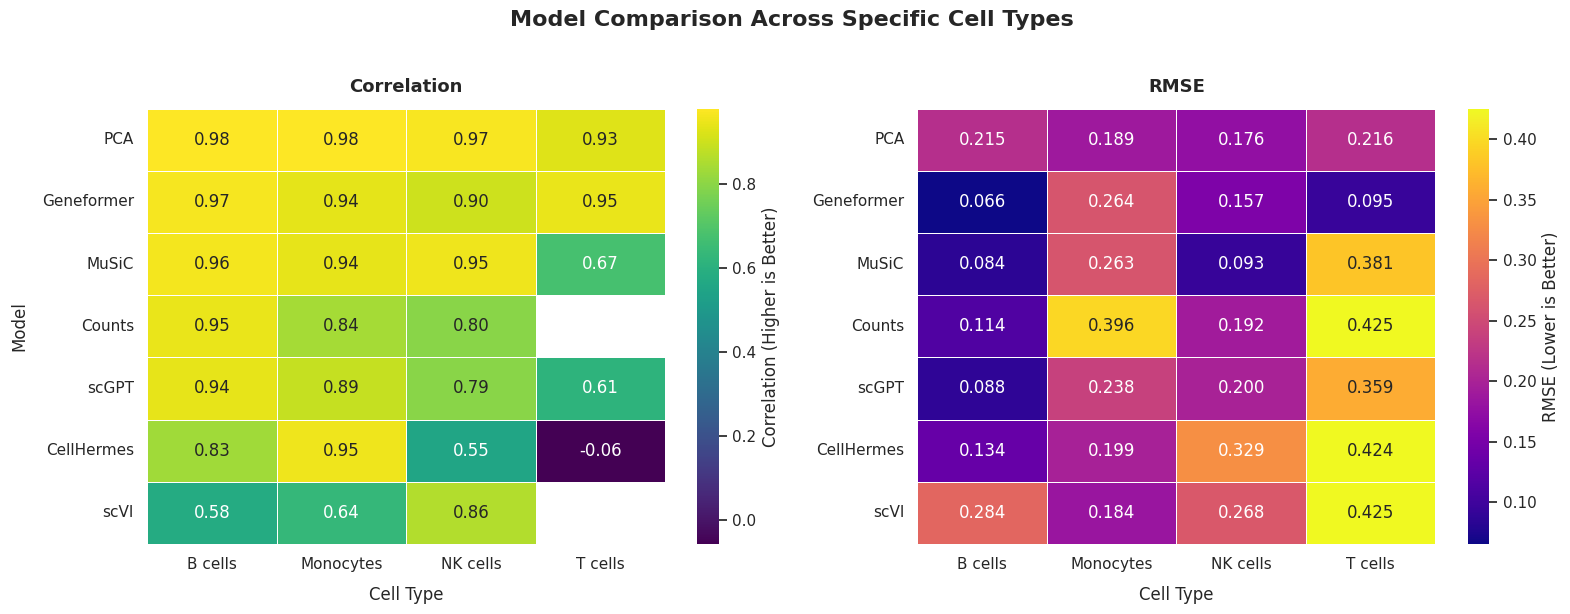

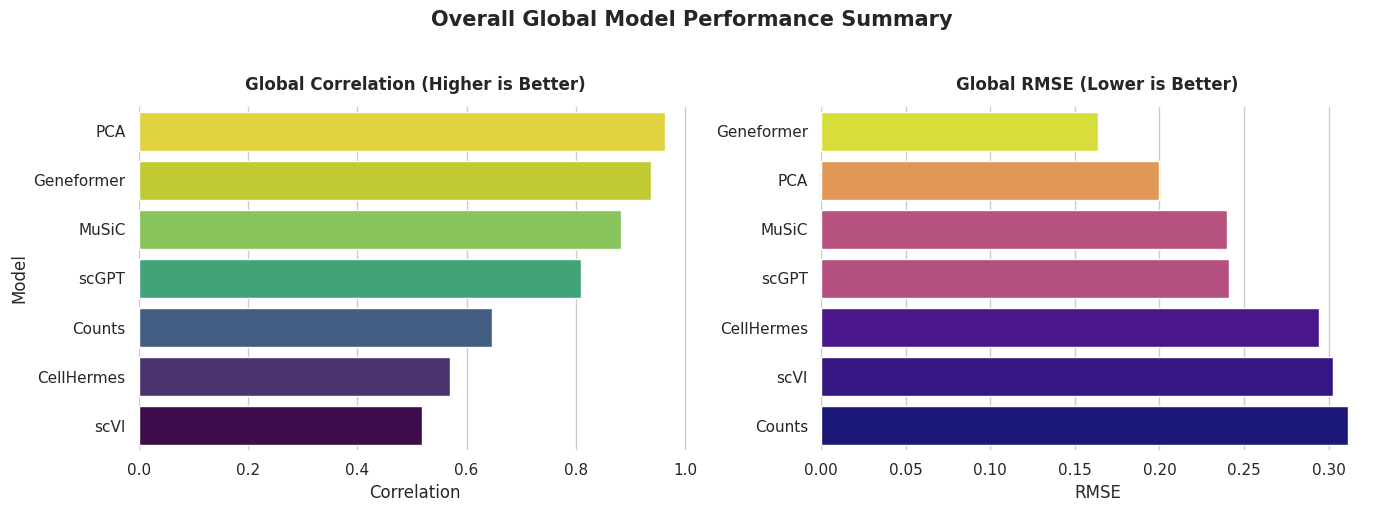

In [12]:
# Remove global correlations/RMSEs
res_df_cell_type = res_df[res_df['CellType'] != 'Global'].copy()
res_df_global = res_df[res_df['CellType'] == 'Global'].copy()

# Plot
plot_cell_type_heatmaps(res_df_cell_type)
plot_global_comparison(res_df_global)